In [1]:
%pip install kagglehub opencv-python-headless numpy pandas tqdm scikit-learn matplotlib seaborn tensorflow -q



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU disponivel:", tf.config.list_physical_devices("GPU"))


/home/apoloo/miniconda3/envs/tf_ESP/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-24 19:59:09.094599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-24 19:59:09.395995: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-24 19:59:11.073299: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slight

TensorFlow: 2.20.0
GPU disponivel: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [37]:
import kagglehub

path = kagglehub.dataset_download("tombackert/brain-tumor-mri-data")
dataset_path = Path(path)

INPUT_BASE = dataset_path / "brain-tumor-mri-dataset"
CLASSES = ["glioma", "meningioma", "notumor", "pituitary"]
TARGET_SIZE = (224, 224)
BASE_DIR = Path.cwd()

## Fazendo a divisão em train/val/test (estratificado)

In [4]:
def listar_arquivos_por_classe(input_base, classes):
    dados = {}
    for c in classes:
        class_dir = input_base / c
        arquivos = sorted([f for f in class_dir.glob("*") if f.is_file()])
        dados[c] = arquivos
    return dados


def criar_split(input_base, classes, val_size=0.15, test_size=0.15, seed=SEED):
    """Split estratificado train/val/test a partir das pastas de classe originais."""
    dados = listar_arquivos_por_classe(input_base, classes)
    registros = []

    for classe, arquivos in dados.items():
        if len(arquivos) == 0:
            raise ValueError(f"Nenhum arquivo encontrado para a classe '{classe}' em {input_base / classe}")

        train_val, test = train_test_split(
            arquivos, test_size=test_size, random_state=seed, shuffle=True
        )
        val_fraction_of_train_val = val_size / (1 - test_size)
        train, val = train_test_split(
            train_val, test_size=val_fraction_of_train_val, random_state=seed, shuffle=True
        )

        for f in train:
            registros.append({"filepath": str(f), "classe": classe, "split": "train"})
        for f in val:
            registros.append({"filepath": str(f), "classe": classe, "split": "val"})
        for f in test:
            registros.append({"filepath": str(f), "classe": classe, "split": "test"})

    return pd.DataFrame(registros)


df_split = criar_split(INPUT_BASE, CLASSES)
print(df_split.groupby(["split", "classe"]).size().unstack())
print("\nTotal de imagens:", len(df_split))

df_split.to_csv(BASE_DIR / "split_baseline.csv", index=False)


classe  glioma  meningioma  notumor  pituitary
split                                         
test       244         267      300        264
train     1133        1241     1400       1229
val        244         267      300        264

Total de imagens: 7153


In [5]:
def construir_cnn(input_shape=(224, 224, 1), n_classes=4, seed=SEED):
    tf.random.set_seed(seed)

    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(n_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


construir_cnn().summary()

I0000 00:00:1782341955.453079    5851 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 4164 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 6GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 128)  │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 83,780 (327.27 KB)

 Trainable params: 83,396 (325.77 KB)

 Non-trainable params: 384 (1.50 KB)

# Treino com o Base:

In [6]:
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    zoom_range=0.1,
    horizontal_flip=True,
)
eval_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

def criar_generator(datagen, df, shuffle):
    return datagen.flow_from_dataframe(
        df,
        x_col="filepath",
        y_col="classe",
        target_size=TARGET_SIZE,
        color_mode="grayscale",
        classes=CLASSES,
        class_mode="categorical",
        batch_size=BATCH_SIZE,
        seed=SEED,
        shuffle=shuffle,
    )

train_gen = criar_generator(train_datagen, df_split[df_split["split"] == "train"], shuffle=True)
val_gen = criar_generator(eval_datagen, df_split[df_split["split"] == "val"], shuffle=False)
test_gen = criar_generator(eval_datagen, df_split[df_split["split"] == "test"], shuffle=False)


Found 5003 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.


In [7]:
EPOCHS = 40
RESULTADOS_DIR = BASE_DIR / "resultados_modelo_base"
RESULTADOS_DIR.mkdir(exist_ok=True)

class_weights_array = compute_class_weight(class_weight="balanced",classes=np.arange(len(CLASSES)),y=train_gen.classes,)
class_weights = dict(enumerate(class_weights_array))
print("Class weights:", class_weights)

model = construir_cnn(input_shape=(*TARGET_SIZE, 1), n_classes=len(CLASSES))

checkpoint_path = RESULTADOS_DIR / "melhor_modelo.keras"
cbs = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(checkpoint_path), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=cbs,
    verbose=1,
)

pd.DataFrame(history.history).to_csv(RESULTADOS_DIR / "history.csv", index=False)


Class weights: {0: np.float64(1.1039276257722859), 1: np.float64(1.007856567284448), 2: np.float64(0.8933928571428571), 3: np.float64(1.0176973148901547)}


/home/apoloo/miniconda3/envs/tf_ESP/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40


2026-06-24 19:59:18.520704: I external/local_xla/xla/service/service.cc:163] XLA service 0x7ef64c004410 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-24 19:59:18.520722: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 6GB Laptop GPU, Compute Capability 8.6
2026-06-24 19:59:18.631033: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-24 19:59:18.934864: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
2026-06-24 19:59:19.052028: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-24 19:59

  1/157 ━━━━━━━━━━━━━━━━━━━━ 40:15 15s/step - accuracy: 0.2500 - loss: 1.5069

I0000 00:00:1782341972.339841    6153 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.5642 - loss: 1.0353

2026-06-24 20:00:06.093364: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-06-24 20:00:06.668494: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_149', 24 bytes spill stores, 24 bytes spill loads

2026-06-24 20:00:06.703295: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_149', 36 bytes spill stores, 36 bytes spill loads



157/157 ━━━━━━━━━━━━━━━━━━━━ 52s 232ms/step - accuracy: 0.5646 - loss: 1.0347 - val_accuracy: 0.2456 - val_loss: 1.6231 - learning_rate: 0.0010
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 166ms/step - accuracy: 0.6843 - loss: 0.7878 - val_accuracy: 0.2456 - val_loss: 2.1541 - learning_rate: 0.0010
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - accuracy: 0.7274 - loss: 0.6880 - val_accuracy: 0.4493 - val_loss: 1.4516 - learning_rate: 0.0010
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 167ms/step - accuracy: 0.7526 - loss: 0.6526 - val_accuracy: 0.6037 - val_loss: 0.9309 - learning_rate: 0.0010
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 158ms/step - accuracy: 0.7769 - loss: 0.5978 - val_accuracy: 0.5842 - val_loss: 1.0607 - learning_rate: 0.0010
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.7761 - loss: 0.5847 - val_accuracy: 0.6344 - val_loss: 1.2493 - learning_rate: 0.0010
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.8029 - loss:

## Avaliação no conjunto de teste

In [38]:
test_gen.reset()
y_true = test_gen.classes
y_pred_probs = model.predict(test_gen, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

report = classification_report(y_true, y_pred, target_names=CLASSES, output_dict=True)
print(classification_report(y_true, y_pred, target_names=CLASSES))

pd.DataFrame(report).transpose().to_csv(RESULTADOS_DIR / "classification_report.csv")
print(f"\nAcuracia no teste: {report['accuracy']:.4f}")


              precision    recall  f1-score   support

      glioma       0.92      0.72      0.81       244
  meningioma       0.76      0.59      0.67       267
     notumor       0.90      0.98      0.94       300
   pituitary       0.74      0.98      0.85       264

    accuracy                           0.83      1075
   macro avg       0.83      0.82      0.82      1075
weighted avg       0.83      0.83      0.82      1075


Acuracia no teste: 0.8270


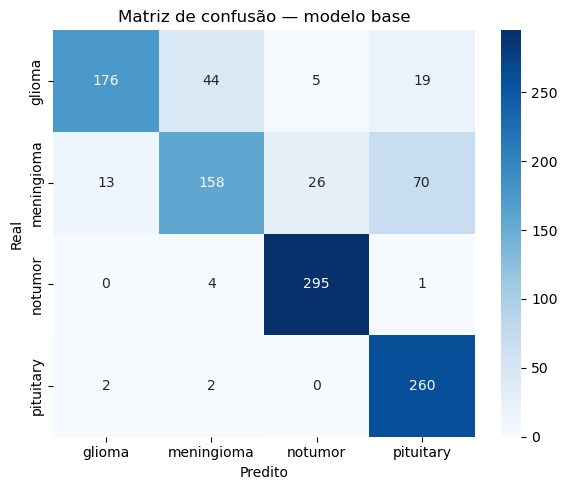

In [39]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão — modelo base")
plt.tight_layout()
plt.savefig(RESULTADOS_DIR / "matriz_confusao.png", dpi=150)
plt.show()


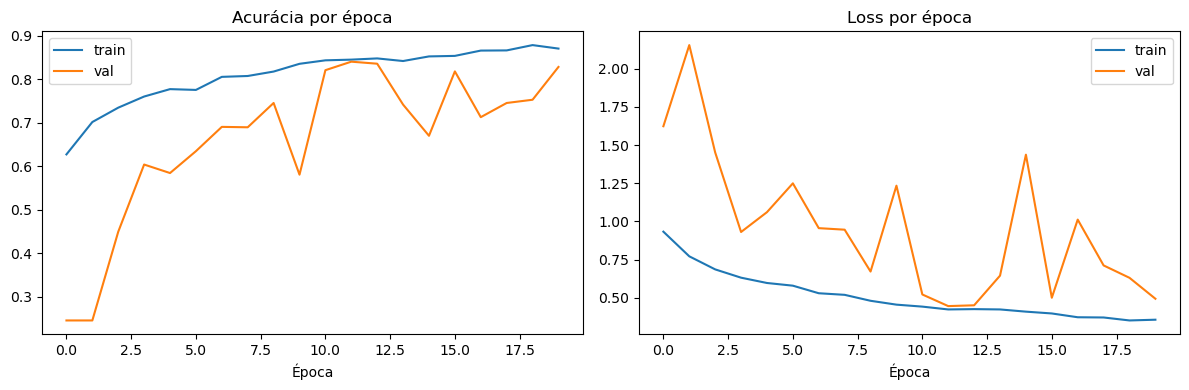

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Acurácia por época")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss por época")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS_DIR / "curvas_treino.png", dpi=150)
plt.show()


# Experimento 1:

In [52]:
INPUT_BASE_EXP1 = Path("Experiment1") 
TARGET_SIZE_EXP1 = (128, 128)

for c in CLASSES:
    class_dir = INPUT_BASE_EXP1 / c
    n = len(list(class_dir.glob("*"))) if class_dir.exists() else 0
    status = "OK" if class_dir.exists() else "NAO ENCONTRADA -- revise INPUT_BASE_EXP1"
    print(f"{c:12s} -> {class_dir}  [{status}]  ({n} arquivos)")

glioma       -> Experiment1/glioma  [OK]  (1621 arquivos)
meningioma   -> Experiment1/meningioma  [OK]  (1775 arquivos)
notumor      -> Experiment1/notumor  [OK]  (2000 arquivos)
pituitary    -> Experiment1/pituitary  [OK]  (1757 arquivos)


In [53]:
df_split_exp1 = criar_split(INPUT_BASE_EXP1, CLASSES)
print(df_split_exp1.groupby(["split", "classe"]).size().unstack())
print("\nTotal de imagens:", len(df_split_exp1))

df_split_exp1.to_csv(BASE_DIR / "split_dataset_exp1.csv", index=False)

classe  glioma  meningioma  notumor  pituitary
split                                         
test       244         267      300        264
train     1133        1241     1400       1229
val        244         267      300        264

Total de imagens: 7153


In [54]:
train_gen_exp1 = criar_generator(train_datagen, df_split_exp1[df_split_exp1["split"] == "train"], shuffle=True)
val_gen_exp1   = criar_generator(eval_datagen, df_split_exp1[df_split_exp1["split"] == "val"], shuffle=False)
test_gen_exp1  = criar_generator(eval_datagen, df_split_exp1[df_split_exp1["split"] == "test"], shuffle=False)

Found 5003 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.
Found 1075 validated image filenames belonging to 4 classes.


In [55]:
EPOCHS_EXP1 = 40
RESULTADOS_DIR_EXP1 = BASE_DIR / "resultados_modelo_exp1"
RESULTADOS_DIR_EXP1.mkdir(exist_ok=True)

class_weights_array_exp1 = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_gen_exp1.classes,
)
class_weights_exp1 = dict(enumerate(class_weights_array_exp1))
print("Class weights:", class_weights_exp1)

model_exp1 = construir_cnn(input_shape=(*TARGET_SIZE_EXP1, 1), n_classes=len(CLASSES))

checkpoint_path_exp1 = RESULTADOS_DIR_EXP1 / "melhor_modelo.keras"
cbs_exp1 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(checkpoint_path_exp1), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history_exp1 = model_exp1.fit(
    train_gen_exp1,
    validation_data=val_gen_exp1,
    epochs=EPOCHS_EXP1,
    class_weight=class_weights_exp1,
    callbacks=cbs_exp1,
    verbose=1,
)

pd.DataFrame(history_exp1.history).to_csv(RESULTADOS_DIR_EXP1 / "history.csv", index=False)

Class weights: {0: np.float64(1.1039276257722859), 1: np.float64(1.007856567284448), 2: np.float64(0.8933928571428571), 3: np.float64(1.0176973148901547)}
Epoch 1/40


/home/apoloo/miniconda3/envs/tf_ESP/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


157/157 ━━━━━━━━━━━━━━━━━━━━ 32s 177ms/step - accuracy: 0.5071 - loss: 1.1421 - val_accuracy: 0.2791 - val_loss: 1.6036 - learning_rate: 0.0010
Epoch 2/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.6376 - loss: 0.8862 - val_accuracy: 0.2791 - val_loss: 2.0231 - learning_rate: 0.0010
Epoch 3/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.6875 - loss: 0.7587 - val_accuracy: 0.2791 - val_loss: 1.6282 - learning_rate: 0.0010
Epoch 4/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 153ms/step - accuracy: 0.7511 - loss: 0.6488 - val_accuracy: 0.5656 - val_loss: 1.0519 - learning_rate: 0.0010
Epoch 5/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.7729 - loss: 0.6010 - val_accuracy: 0.4447 - val_loss: 1.8993 - learning_rate: 0.0010
Epoch 6/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.7702 - loss: 0.5900 - val_accuracy: 0.3023 - val_loss: 2.2827 - learning_rate: 0.0010
Epoch 7/40
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 152ms/step - accuracy: 0.8000 - loss:

In [56]:
test_gen_exp1.reset()
y_true_exp1 = test_gen_exp1.classes
y_pred_probs_exp1 = model_exp1.predict(test_gen_exp1, verbose=0)
y_pred_exp1 = np.argmax(y_pred_probs_exp1, axis=1)

report_exp1 = classification_report(y_true_exp1, y_pred_exp1, target_names=CLASSES, output_dict=True)
print(classification_report(y_true_exp1, y_pred_exp1, target_names=CLASSES))

pd.DataFrame(report_exp1).transpose().to_csv(RESULTADOS_DIR_EXP1 / "classification_report.csv")
print(f"\nAcuracia no teste: {report_exp1['accuracy']:.4f}")

              precision    recall  f1-score   support

      glioma       0.87      0.83      0.85       244
  meningioma       0.83      0.70      0.76       267
     notumor       0.88      0.99      0.93       300
   pituitary       0.90      0.95      0.92       264

    accuracy                           0.87      1075
   macro avg       0.87      0.87      0.87      1075
weighted avg       0.87      0.87      0.87      1075


Acuracia no teste: 0.8726


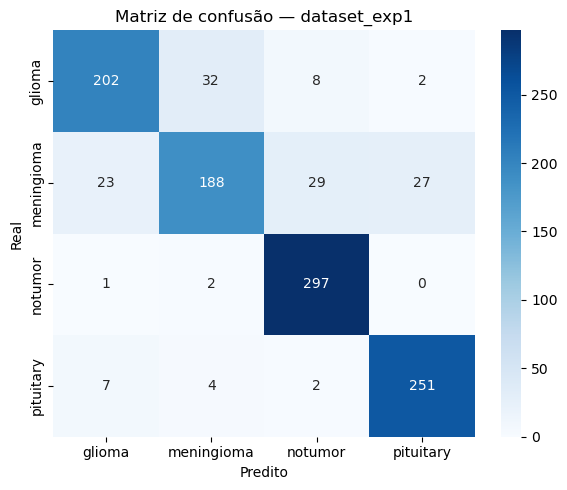

In [57]:
cm_exp1 = confusion_matrix(y_true_exp1, y_pred_exp1)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_exp1, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão — dataset_exp1")
plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP1 / "matriz_confusao.png", dpi=150)
plt.show()

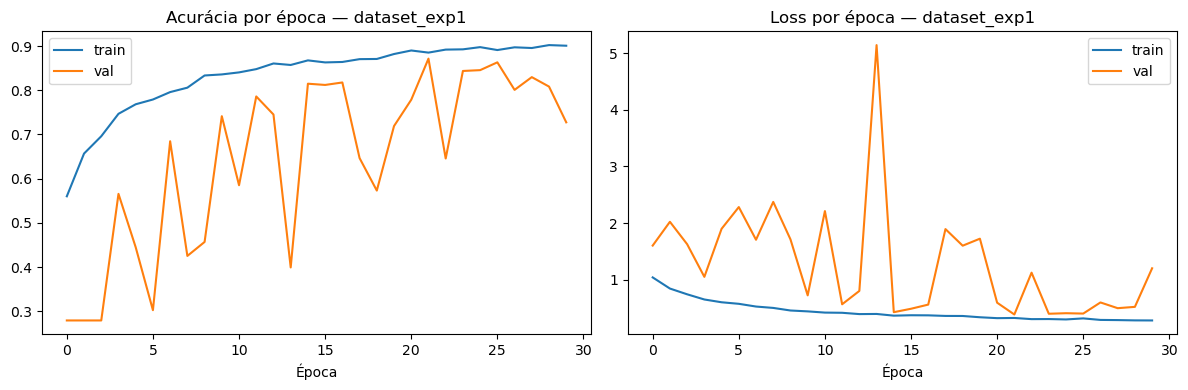

In [58]:
history_df_exp1 = pd.read_csv(RESULTADOS_DIR_EXP1 / "history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df_exp1["accuracy"], label="train")
axes[0].plot(history_df_exp1["val_accuracy"], label="val")
axes[0].set_title("Acurácia por época — dataset_exp1")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_df_exp1["loss"], label="train")
axes[1].plot(history_df_exp1["val_loss"], label="val")
axes[1].set_title("Loss por época — dataset_exp1")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP1 / "curvas_treino.png", dpi=150)
plt.show()

# Experimento 2:

In [59]:
INPUT_BASE_EXP2 = Path("Experiment2") 
TARGET_SIZE_EXP2 = (128, 128)

for c in CLASSES:
    class_dir = INPUT_BASE_EXP2 / c
    n = len(list(class_dir.glob("*"))) if class_dir.exists() else 0
    status = "OK" if class_dir.exists() else "NAO ENCONTRADA -- revise INPUT_BASE_EXP2"
    print(f"{c:12s} -> {class_dir}  [{status}]  ({n} arquivos)")

glioma       -> Experiment2/glioma  [OK]  (3242 arquivos)
meningioma   -> Experiment2/meningioma  [OK]  (3550 arquivos)
notumor      -> Experiment2/notumor  [OK]  (4000 arquivos)
pituitary    -> Experiment2/pituitary  [OK]  (3514 arquivos)


In [60]:
df_split_exp2 = criar_split(INPUT_BASE_EXP2, CLASSES)
print(df_split_exp2.groupby(["split", "classe"]).size().unstack())
print("\nTotal de imagens:", len(df_split_exp2))

df_split_exp2.to_csv(BASE_DIR / "split_dataset_exp1.csv", index=False)

classe  glioma  meningioma  notumor  pituitary
split                                         
test       487         533      600        528
train     2268        2484     2800       2459
val        487         533      600        527

Total de imagens: 14306


In [61]:
train_gen_exp2 = criar_generator(train_datagen, df_split_exp2[df_split_exp2["split"] == "train"], shuffle=True)
val_gen_exp2   = criar_generator(eval_datagen, df_split_exp2[df_split_exp2["split"] == "val"], shuffle=False)
test_gen_exp2  = criar_generator(eval_datagen, df_split_exp2[df_split_exp2["split"] == "test"], shuffle=False)

Found 10011 validated image filenames belonging to 4 classes.
Found 2147 validated image filenames belonging to 4 classes.
Found 2148 validated image filenames belonging to 4 classes.


In [62]:
EPOCHS_EXP2 = 40
RESULTADOS_DIR_EXP2 = BASE_DIR / "resultados_modelo_exp2"
RESULTADOS_DIR_EXP2.mkdir(exist_ok=True)

class_weights_array_exp2 = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=train_gen_exp2.classes,
)
class_weights_exp2 = dict(enumerate(class_weights_array_exp2))
print("Class weights:", class_weights_exp2)

model_exp2 = construir_cnn(input_shape=(*TARGET_SIZE_EXP2, 1), n_classes=len(CLASSES))

checkpoint_path_exp2 = RESULTADOS_DIR_EXP2 / "melhor_modelo.keras"
cbs_exp2 = [
    callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    callbacks.ModelCheckpoint(str(checkpoint_path_exp2), monitor="val_loss", save_best_only=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
]

history_exp2 = model_exp2.fit(
    train_gen_exp2,
    validation_data=val_gen_exp2,
    epochs=EPOCHS_EXP2,
    class_weight=class_weights_exp2,
    callbacks=cbs_exp2,
    verbose=1,
)

pd.DataFrame(history_exp2.history).to_csv(RESULTADOS_DIR_EXP2 / "history.csv", index=False)

Class weights: {0: np.float64(1.103505291005291), 1: np.float64(1.007548309178744), 2: np.float64(0.8938392857142857), 3: np.float64(1.0177917852785685)}


/home/apoloo/miniconda3/envs/tf_ESP/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 194ms/step - accuracy: 0.6250 - loss: 0.9436 - val_accuracy: 0.2487 - val_loss: 1.9789 - learning_rate: 0.0010
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 177ms/step - accuracy: 0.7643 - loss: 0.6323 - val_accuracy: 0.6246 - val_loss: 0.9041 - learning_rate: 0.0010
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 172ms/step - accuracy: 0.7923 - loss: 0.5684 - val_accuracy: 0.4304 - val_loss: 2.1477 - learning_rate: 0.0010
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.8123 - loss: 0.5156 - val_accuracy: 0.6754 - val_loss: 1.1254 - learning_rate: 0.0010
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 165ms/step - accuracy: 0.8164 - loss: 0.5019 - val_accuracy: 0.5976 - val_loss: 1.2803 - learning_rate: 0.0010
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 166ms/step - accuracy: 0.8469 - loss: 0.4262 - val_accuracy: 0.5706 - val_loss: 1.4086 - learning_rate: 0.0010
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 56s 178ms/step - accuracy: 0.8

In [63]:
test_gen_exp2.reset()
y_true_exp2 = test_gen_exp2.classes
y_pred_probs_exp2 = model_exp2.predict(test_gen_exp2, verbose=0)
y_pred_exp2 = np.argmax(y_pred_probs_exp2, axis=1)

report_exp2 = classification_report(y_true_exp2, y_pred_exp2, target_names=CLASSES, output_dict=True)
print(classification_report(y_true_exp2, y_pred_exp2, target_names=CLASSES))

pd.DataFrame(report_exp2).transpose().to_csv(RESULTADOS_DIR_EXP2 / "classification_report.csv")
print(f"\nAcuracia no teste: {report_exp2['accuracy']:.4f}")

              precision    recall  f1-score   support

      glioma       0.93      0.86      0.90       487
  meningioma       0.87      0.82      0.84       533
     notumor       0.91      0.97      0.94       600
   pituitary       0.91      0.96      0.93       528

    accuracy                           0.90      2148
   macro avg       0.90      0.90      0.90      2148
weighted avg       0.90      0.90      0.90      2148


Acuracia no teste: 0.9046


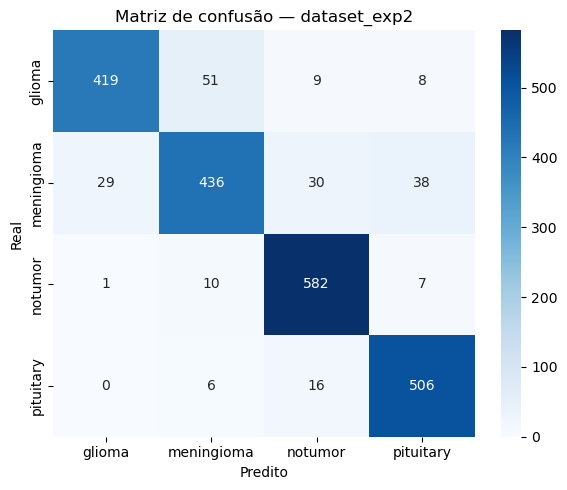

In [64]:
cm_exp2 = confusion_matrix(y_true_exp2, y_pred_exp2)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_exp2, annot=True, fmt="d", cmap="Blues", xticklabels=CLASSES, yticklabels=CLASSES)
plt.xlabel("Predito")
plt.ylabel("Real")
plt.title("Matriz de confusão — dataset_exp2")
plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP2 / "matriz_confusao.png", dpi=150)
plt.show()

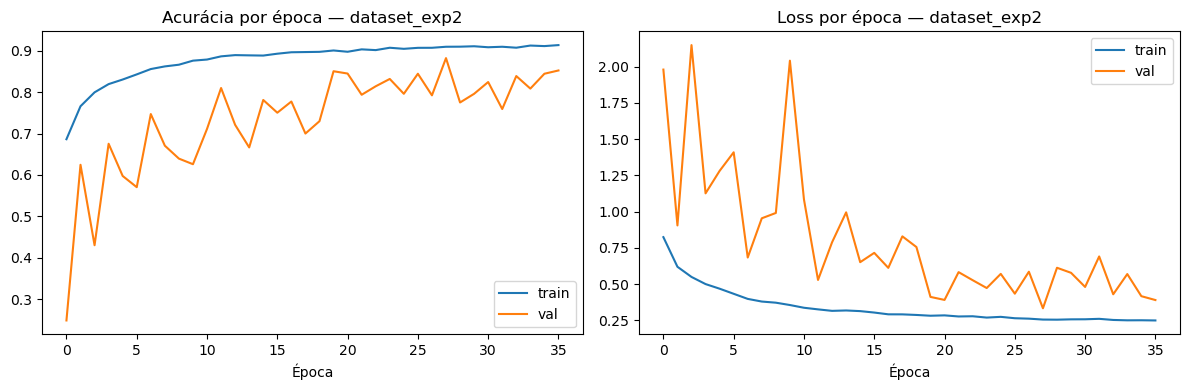

In [65]:
history_df_exp2 = pd.read_csv(RESULTADOS_DIR_EXP2 / "history.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_df_exp2["accuracy"], label="train")
axes[0].plot(history_df_exp2["val_accuracy"], label="val")
axes[0].set_title("Acurácia por época — dataset_exp2")
axes[0].set_xlabel("Época")
axes[0].legend()

axes[1].plot(history_df_exp2["loss"], label="train")
axes[1].plot(history_df_exp2["val_loss"], label="val")
axes[1].set_title("Loss por época — dataset_exp2")
axes[1].set_xlabel("Época")
axes[1].legend()

plt.tight_layout()
plt.savefig(RESULTADOS_DIR_EXP2 / "curvas_treino.png", dpi=150)
plt.show()